# ***PyTorch NN***

# *Import Libraries*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import torch
# TensorDataset: Wraps tensors into a dataset
# DataLoader: Handles batching, shuffling, and iteration
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

# *Load & Prepare Dataset*

In [2]:
# Reading data and converting it to DataFrame
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

# Features and target
X = df.drop('Target', axis=1).values
y = df['Target'].values.reshape(-1, 1) # Reshape the target

# Train-test split (67% training, 33% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fits on training data and scales it
X_test = scaler.transform(X_test) # Applies the same transformation to the test data

In [3]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create Dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# batch_size=32: Processes 32 examples at a time
# shuffle=True: Randomly shuffles data each epoch
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# *Build NN*

In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__() # Inherits from nn.Module
        self.hidden1 = nn.Linear(8, 5)   # Input -> Hidden1
        self.hidden2 = nn.Linear(5, 3)   # Hidden1 -> Hidden2
        self.output = nn.Linear(3, 1)    # Hidden2 -> Output
        self.relu = nn.ReLU()    # ReLU activation function

    def forward(self, x): # Defines the computation graph
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        return self.output(x)

model = NeuralNetwork()

# *Define Loss & optimizer*

In [5]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()
# model.parameters(): Returns all weights and biases
# lr=0.001: Learning rate controls step size
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# *Train Model*

In [6]:
train_losses = [] # Stores loss
epochs = 100 # Total training iterations

for epoch in range(epochs):
    model.train() # Set to training mode
    batch_losses = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()  # Clear previous gradients
        predictions = model(X_batch)  # Forward pass
        loss = criterion(predictions, y_batch)  # Calculate loss
        loss.backward()   # Compute gradients
        optimizer.step()  # Update weights
        batch_losses.append(loss.item())  # Record batch loss

    epoch_loss = np.mean(batch_losses)
    train_losses.append(epoch_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 10/100, Loss: 0.4145
Epoch 20/100, Loss: 0.3960
Epoch 30/100, Loss: 0.3869
Epoch 40/100, Loss: 0.3841
Epoch 50/100, Loss: 0.3840
Epoch 60/100, Loss: 0.3825
Epoch 70/100, Loss: 0.3825
Epoch 80/100, Loss: 0.3815
Epoch 90/100, Loss: 0.3805
Epoch 100/100, Loss: 0.3801


# *Plot Training Loss*

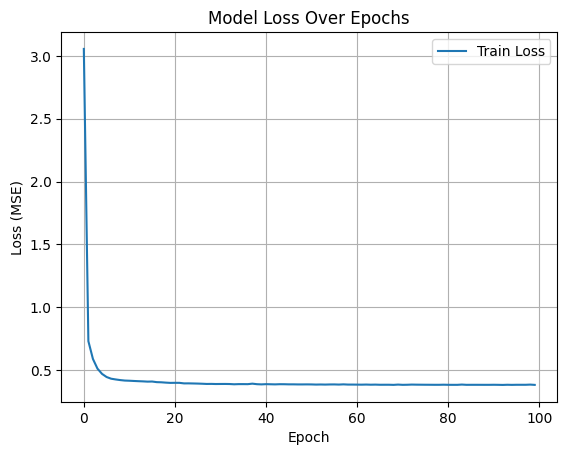

In [7]:
plt.plot(train_losses, label='Train Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# *Evaluate Model*

In [8]:
# Ensure reliable and consistent predictions
model.eval()

# Disable gradient tracking (we aren't going to update the model anymore)
with torch.no_grad():

    # Returns MSE and MAE on the test set
    predictions = model(X_test_tensor)
    mse = criterion(predictions, y_test_tensor).item()
    mae = torch.mean(torch.abs(predictions - y_test_tensor)).item()

print(f"Test Loss (MSE): {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss (MSE): 0.3855
Test MAE: 0.4352
